In [2]:
import matplotlib.pyplot as plt
import numpy as np
import scipy as sp
import pandas as pd
import os
import gc
import sys

sys.path.insert(0, '..')
from src import *

# NVE + NVT equilibration

## Velocity const

In [225]:
path = Filepaths.DATA.value / 'strains' / 'N4000' / 'T4.0_nve_nvt' / 'dt0.001'
data = Data(path)
observ = data.read(['thermo', 'press'], dropdup=['timestep'])
thermo_data = data.read_df(['thermo'], dropdup=['timestep'])['thermo']
V = observ['V']
T = observ['T']
stress = observ['stress']

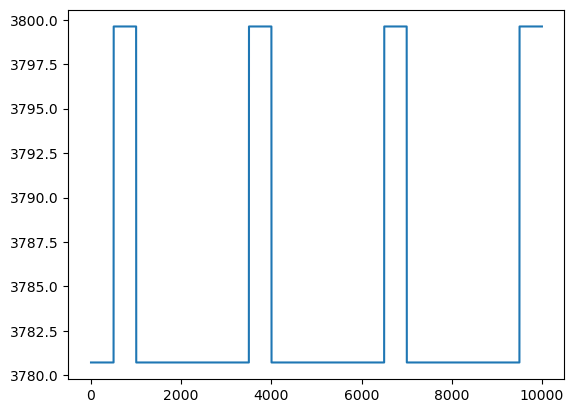

In [226]:
plt.plot(thermo_data.vol[:10000])

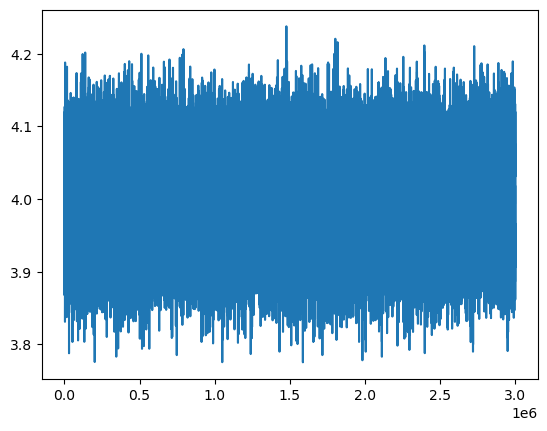

In [200]:
#plt.plot(sp.ndimage.gaussian_filter(thermo_data.temp, 1000))
plt.plot(thermo_data.temp)

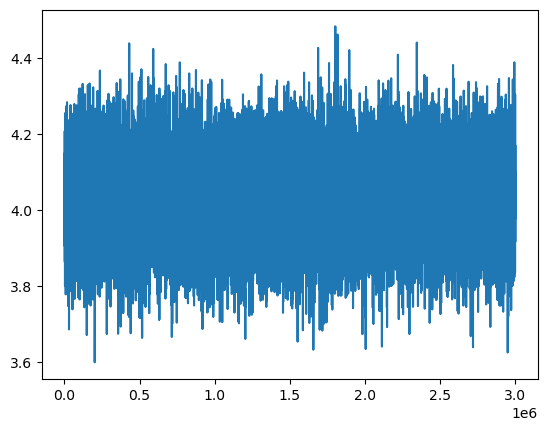

In [201]:
plt.plot(thermo_data.energy)

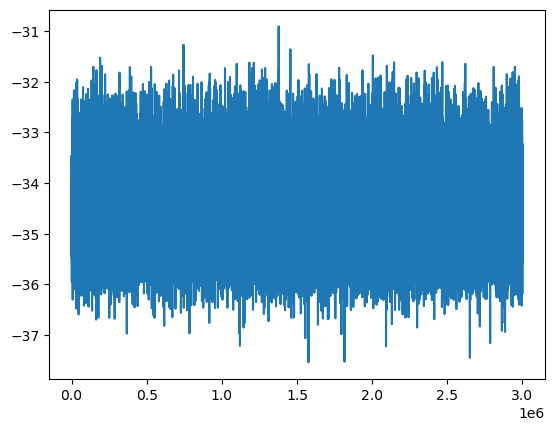

In [202]:
plt.plot(stress[:, 0, 0])

In [203]:
stress.shape

(3000501, 3, 3)

In [227]:
cycle_size = 3_000
num_cycles = 1000
stress_cycle = np.zeros(cycle_size)
energy_cycle = np.zeros_like(stress_cycle)
stress_avg = 0
for cycle in range(1, num_cycles):
    s0 = cycle * cycle_size
    s1 = (cycle + 1) * cycle_size
    stress_cycle += stress[s0:s1, 0, 0] / (num_cycles - 1)
    energy_cycle += np.array(thermo_data.energy)[s0:s1] / (num_cycles - 1)
    stress_avg += stress[s1-1000:s1, 0, 0].mean() / (num_cycles - 1)

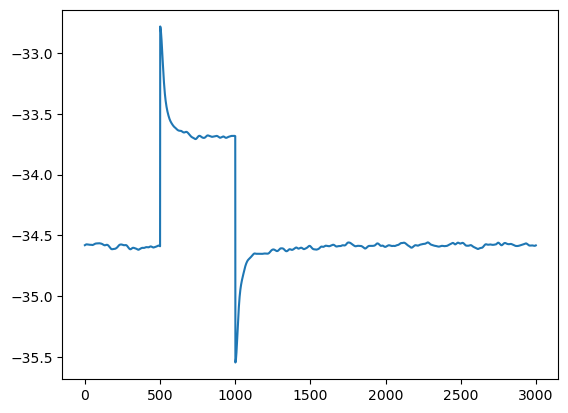

In [205]:
plt.plot(stress_cycle)

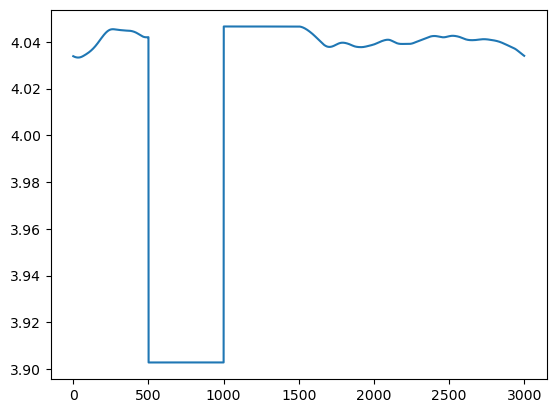

In [206]:
plt.plot(energy_cycle)

In [207]:
pmod = np.loadtxt(Filepaths.DATA.value / 'moduli_t' / 'pwave_dt0.0002')
dt = 0.0002
time_pmod = np.linspace(0, (len(pmod) - 1) * dt, len(pmod))

In [249]:
pmod_nl = np.loadtxt(Filepaths.DATA.value / 'moduli_t' / 'pwave_nonlin_dt0.005')
dt = 0.005
time_pmod_nl = np.linspace(0, (len(pmod_nl) - 1) * dt, len(pmod_nl))
pmod_nl_interp = np.interp(time_pmod, time_pmod_nl, pmod_nl)

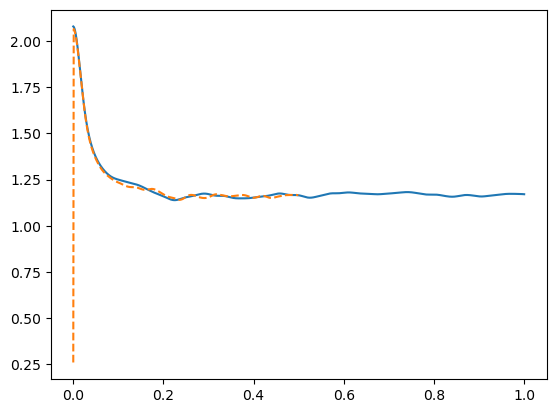

In [276]:
time = np.array(thermo_data.time[:500] - thermo_data.time[0])
#plt.plot(time, stress_cycle[500:1000] - stress_avg, label='numerical')
plt.plot(time_pmod, 0.005 * pmod, label='lin')
#plt.plot(time_pmod, 0.005 * pmod + 0.005**2 * pmod_nl_interp, label='lin+nonlin')
#plt.xlim(0, 0.4)
#plt.legend()
plt.plot(time, stress_cycle[500:1000] - stress_avg + 0.27, '--')

## Velocity remap

In [209]:
path = Filepaths.DATA.value / 'strains' / 'N4000' / 'T4.0_nve_nvt' / 'vel_remap_dt0.001'
data = Data(path)
observ = data.read(['thermo', 'press'], dropdup=['timestep'])
thermo_data = data.read_df(['thermo'], dropdup=['timestep'])['thermo']
V = observ['V']
T = observ['T']
stress = observ['stress']

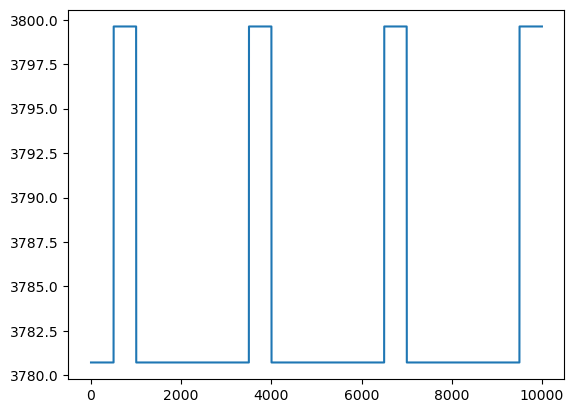

In [210]:
plt.plot(thermo_data.vol[:10000])

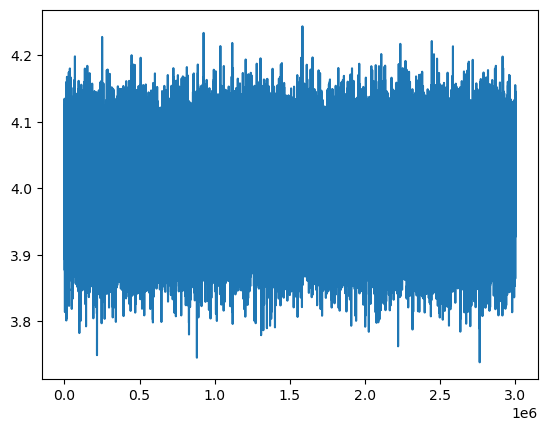

In [211]:
#plt.plot(sp.ndimage.gaussian_filter(thermo_data.temp, 1000))
plt.plot(thermo_data.temp)

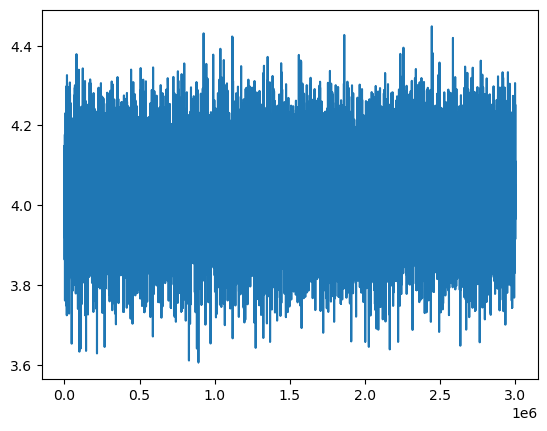

In [212]:
plt.plot(thermo_data.energy)

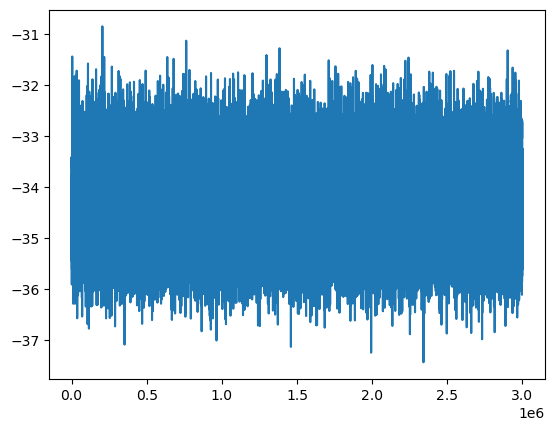

In [213]:
plt.plot(stress[:, 0, 0])

In [214]:
stress.shape

(3000501, 3, 3)

In [221]:
cycle_size = 3_000
num_cycles = 1000
stress_cycle_vr = np.zeros(cycle_size)
energy_cycle_vr = np.zeros(cycle_size)
stress_avg_vr = 0
for cycle in range(1, num_cycles):
    s0 = cycle * cycle_size
    s1 = (cycle + 1) * cycle_size
    stress_cycle_vr += stress[s0:s1, 0, 0] / (num_cycles - 1)
    energy_cycle_vr += np.array(thermo_data.energy)[s0:s1] / (num_cycles - 1)
    stress_avg_vr += stress[s1-1000:s1, 0, 0].mean() / (num_cycles - 1)

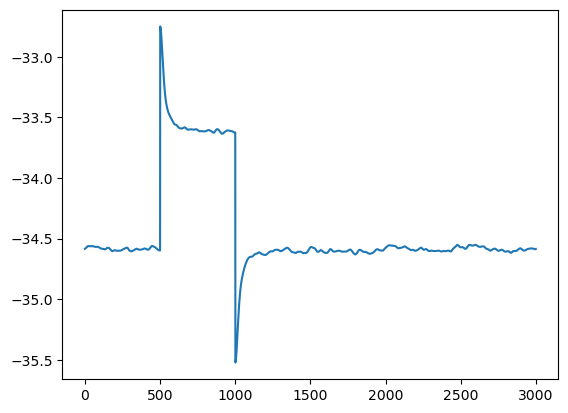

In [222]:
plt.plot(stress_cycle_vr)

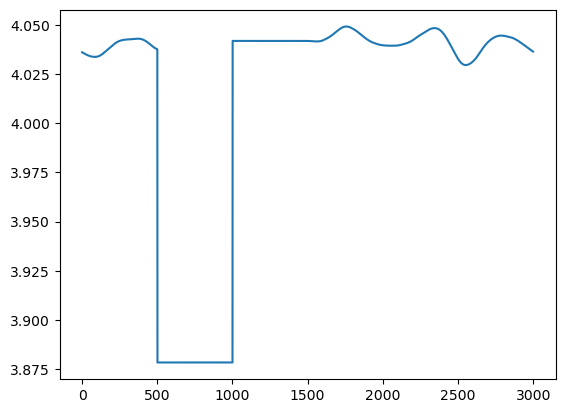

In [223]:
plt.plot(energy_cycle_vr)

In [265]:
pmod = np.loadtxt(Filepaths.DATA.value / 'moduli_t' / 'pwave_dt0.0002')
dt = 0.0002
time_pmod = np.linspace(0, (len(pmod) - 1) * dt, len(pmod))

In [266]:
pmod_nl = np.loadtxt(Filepaths.DATA.value / 'moduli_t' / 'pwave_nonlin_dt0.005')
dt = 0.005
time_pmod_nl = np.linspace(0, (len(pmod_nl) - 1) * dt, len(pmod_nl))
pmod_nl_interp = np.interp(time_pmod, time_pmod_nl, pmod_nl)

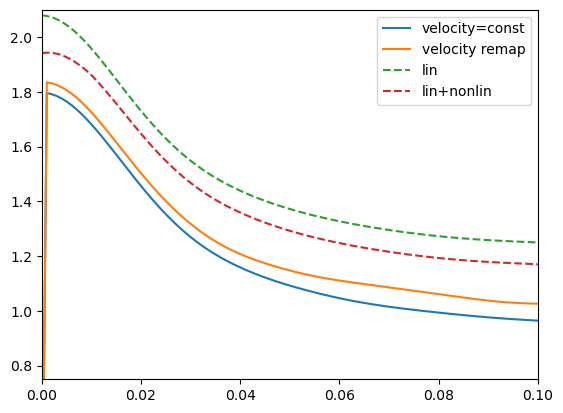

In [268]:
time = np.array(thermo_data.time[:500] - thermo_data.time[0])
plt.plot(time, stress_cycle[500:1000] - stress_avg, label='velocity=const')
plt.plot(time, stress_cycle_vr[500:1000] - stress_avg_vr, label='velocity remap')
plt.plot(time_pmod, 0.005 * pmod, '--', label='lin')
plt.plot(time_pmod, 0.005 * pmod + 0.005**2 * pmod_nl_interp, '--', label='lin+nonlin')
plt.xlim(0, 0.1)
plt.ylim(0.75,2.1)
plt.legend()
#plt.plot(time, stress_cycle_vr[500:1000] - stress_avg_vr + 0.05, '--')

(0.0, 0.1)

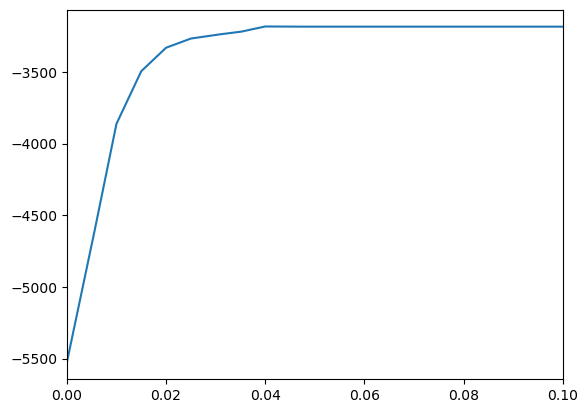

In [263]:
plt.plot(time_pmod, pmod_nl_interp)
plt.xlim(0, 0.1)

# NVE

## Velocity const

In [109]:
path = Filepaths.DATA.value / 'strains' / 'N4000' / 'T4.0_nve' / 'dt0.001'
data = Data(path)
observ = data.read(['thermo', 'press'], dropdup=['timestep'])
thermo_data = data.read_df(['thermo'], dropdup=['timestep'])['thermo']
V = observ['V']
T = observ['T']
stress = observ['stress']

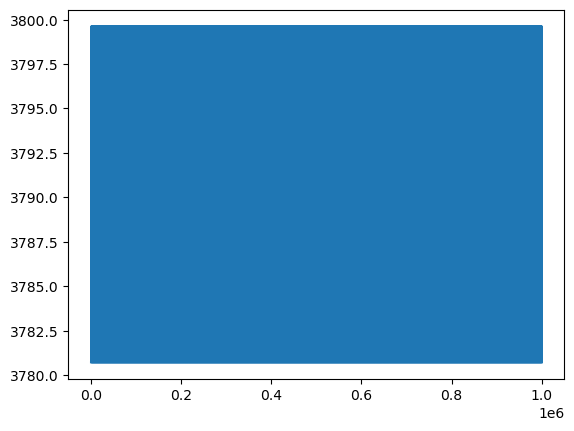

In [110]:
plt.plot(thermo_data.vol)

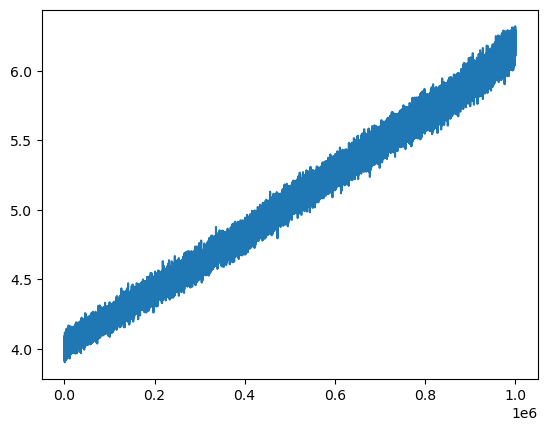

In [80]:
plt.plot(thermo_data.temp)

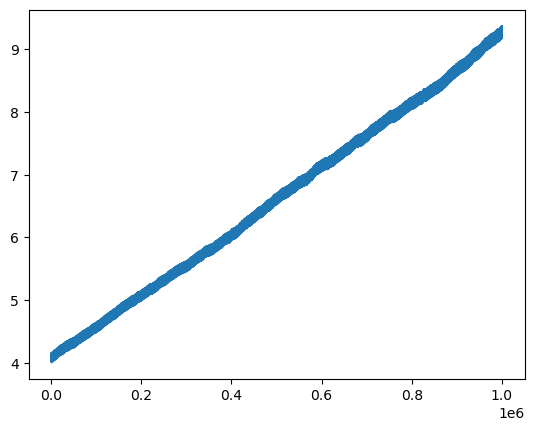

In [65]:
plt.plot(thermo_data.energy)

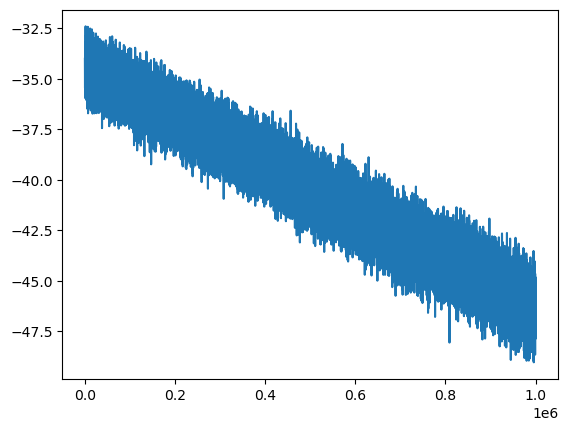

In [66]:
plt.plot(stress[:, 0, 0])

In [67]:
stress.shape

(1000501, 3, 3)

In [68]:
cycle_size = 1_000
num_cycles = 1_000
stress_cycle = np.zeros(cycle_size)
energy_cycle = np.zeros_like(stress_cycle)
for cycle in range(1, num_cycles):
    s0 = cycle * cycle_size
    s1 = (cycle + 1) * cycle_size
    stress_cycle += stress[s0:s1, 0, 0] / (num_cycles - 1)
    energy_cycle += np.array(thermo_data.energy)[s0:s1] / (num_cycles - 1)

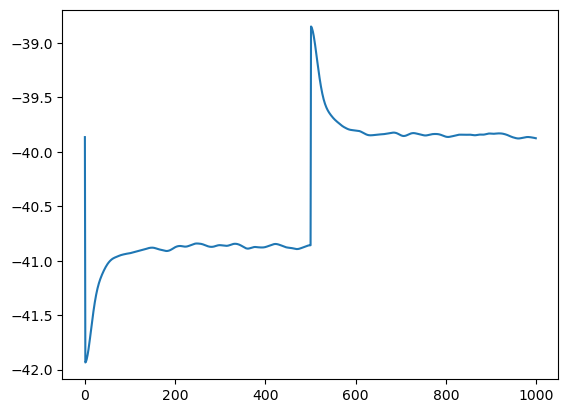

In [69]:
plt.plot(stress_cycle)

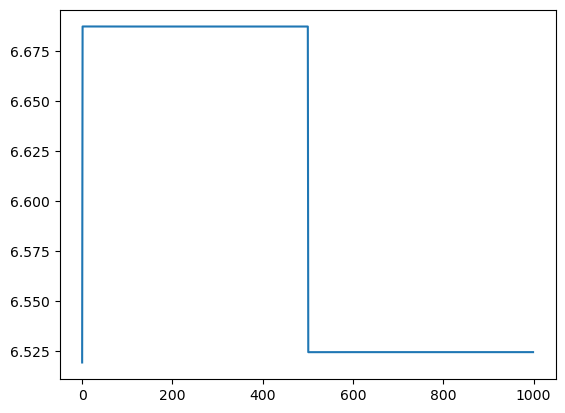

In [70]:
plt.plot(energy_cycle)

## Velocity remap

In [99]:
path = Filepaths.DATA.value / 'strains' / 'N4000' / 'T4.0_nve' / 'vel_remap_dt0.001'
data = Data(path)
observ = data.read(['thermo', 'press'], dropdup=['timestep'])
thermo_data = data.read_df(['thermo'], dropdup=['timestep'])['thermo']
V = observ['V']
T = observ['T']
stress = observ['stress']

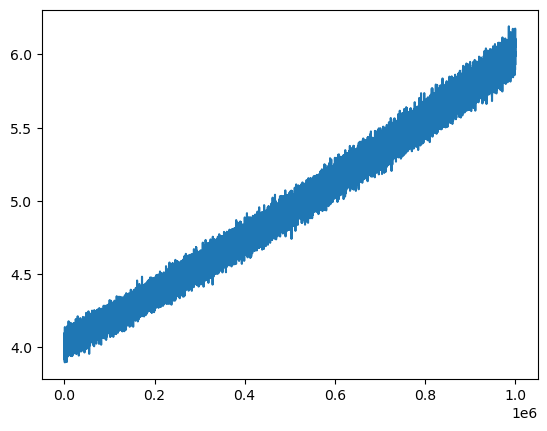

In [100]:
plt.plot(thermo_data.temp)

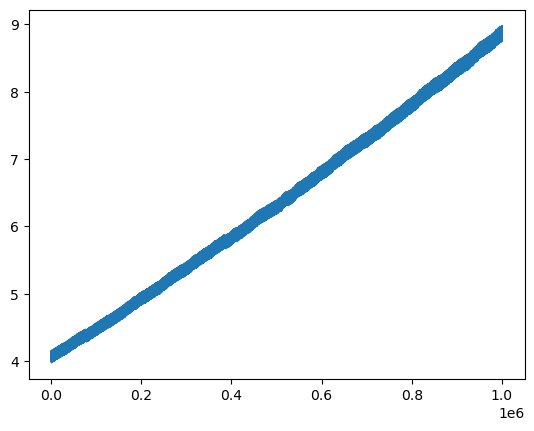

In [101]:
plt.plot(thermo_data.energy)

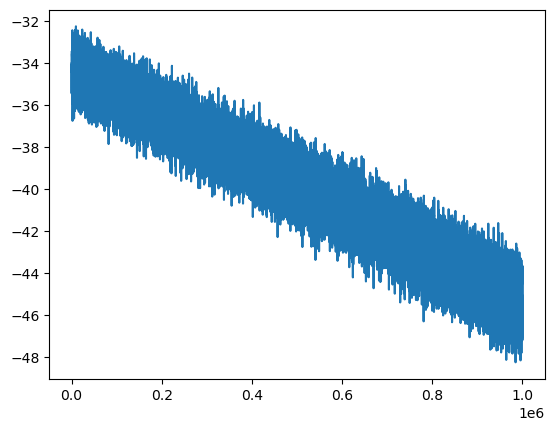

In [102]:
plt.plot(stress[:, 0, 0])

In [103]:
stress.shape

(1000501, 3, 3)

In [111]:
cycle_size = 1_000
num_cycles = 1_000
stress_cycle_vr = np.zeros(cycle_size)
energy_cycle_vr = np.zeros_like(stress_cycle_vr)
temp_cycle_vr = np.zeros_like(stress_cycle_vr)
vol_cycle_vr = np.zeros_like(stress_cycle_vr)
for cycle in range(1, num_cycles):
    s0 = cycle * cycle_size
    s1 = (cycle + 1) * cycle_size
    stress_cycle_vr += stress[s0:s1, 0, 0] / (num_cycles - 1)
    energy_cycle_vr += np.array(thermo_data.energy)[s0:s1] / (num_cycles - 1)
    temp_cycle_vr += np.array(thermo_data.temp)[s0:s1] / (num_cycles - 1)
    vol_cycle_vr += np.array(thermo_data.vol)[s0:s1] / (num_cycles - 1)

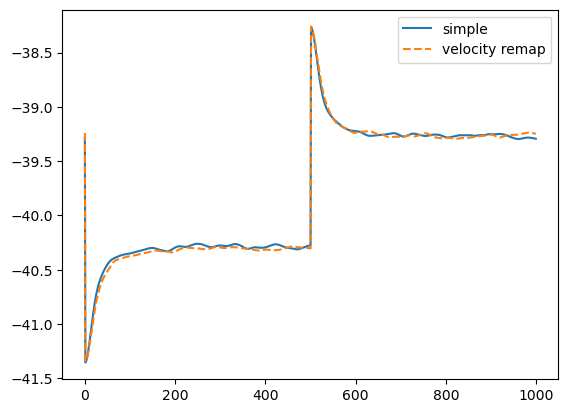

In [105]:
plt.plot(stress_cycle + 0.58, label='simple')
plt.plot(stress_cycle_vr, '--', label='velocity remap')
plt.legend()

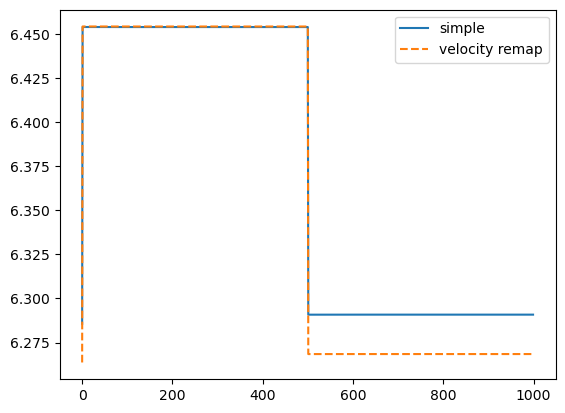

In [106]:
plt.plot(energy_cycle - 0.2335, label='simple')
plt.plot(energy_cycle_vr, '--', label='velocity remap')
#plt.ylim(0,7)
plt.legend()

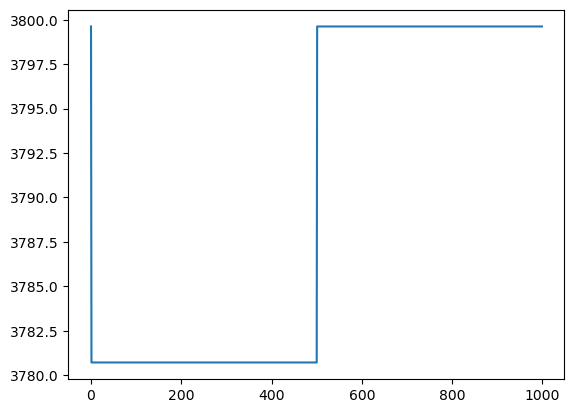

In [112]:
plt.plot(vol_cycle_vr)

# NVT

In [113]:
path = Filepaths.DATA.value / 'strains' / 'N4000' / 'T4.0_nvt' / 'dt0.001'
data = Data(path)
observ = data.read(['thermo', 'press'], dropdup=['timestep'])
thermo_data = data.read_df(['thermo'], dropdup=['timestep'])['thermo']
V = observ['V']
T = observ['T']
stress = observ['stress']

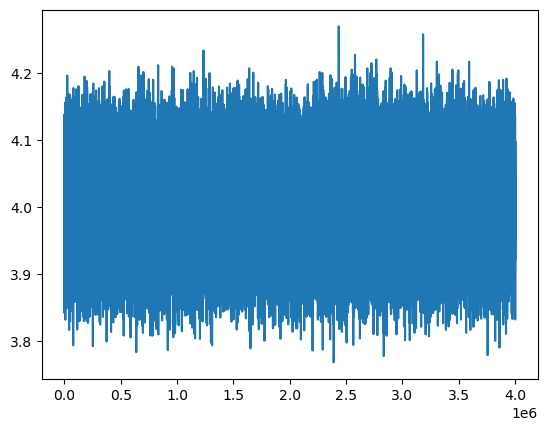

In [114]:
plt.plot(thermo_data.temp)

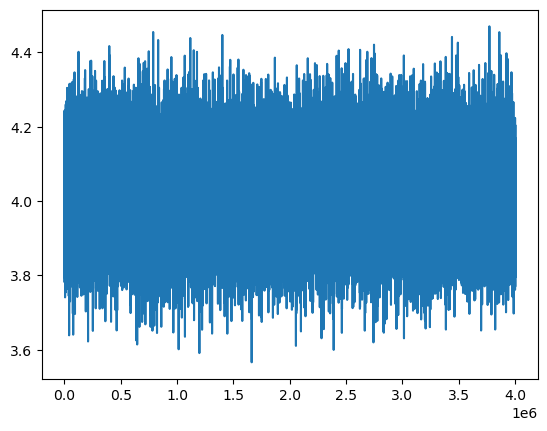

In [115]:
plt.plot(thermo_data.energy)

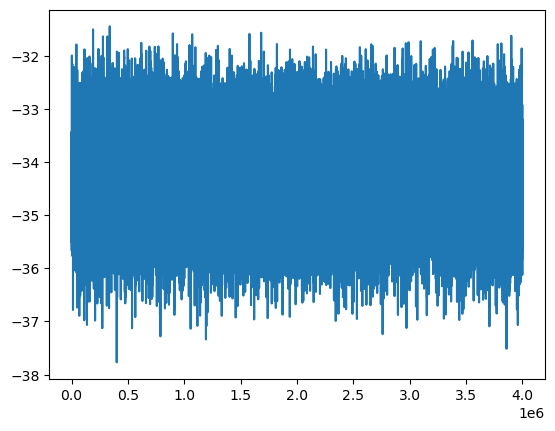

In [116]:
plt.plot(stress[:, 0, 0])

In [117]:
stress.shape

(4002001, 3, 3)

In [118]:
cycle_size = 4_000
num_cycles = 1_000
stress_cycle_nvt = np.zeros(cycle_size)
energy_cycle_nvt = np.zeros_like(stress_cycle_nvt)
for cycle in range(1, num_cycles):
    s0 = cycle * cycle_size
    s1 = (cycle + 1) * cycle_size
    stress_cycle_nvt += stress[s0:s1, 0, 0] / (num_cycles - 1)
    energy_cycle_nvt += np.array(thermo_data.energy)[s0:s1] / (num_cycles - 1)

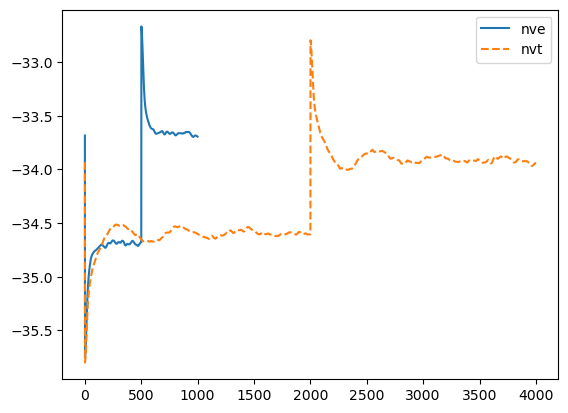

In [119]:
plt.plot(stress_cycle + 6.18, label='nve')
plt.plot(stress_cycle_nvt, '--', label='nvt')
plt.legend()

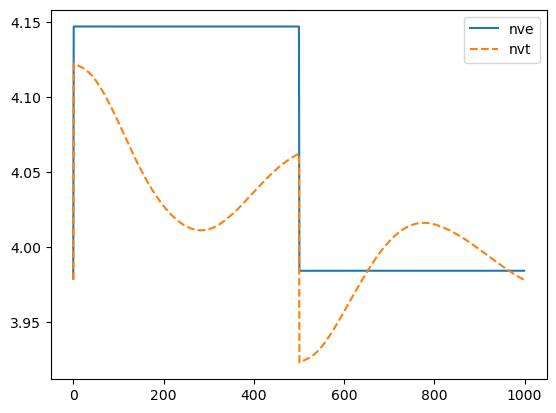

In [98]:
plt.plot(energy_cycle - 2.54, label='nve')
plt.plot(energy_cycle_nvt, '--', label='nvt')
#plt.ylim(0,7)
plt.legend()